# Integración del dataset: Health Percentage y GDP (2000–2023)

Este notebook descarga seis indicadores de Our World in Data, los prepara y los integra por `entity` y `year`. El resultado final contiene **exactamente ocho columnas**: `entity`, `year`, `population`, `births`, `deaths`, `child_deaths_under_5`, `percentage_health` y `gdp`.

## Dependencias

Si el entorno de Jupyter no tiene las librerías, ejecuta una vez la siguiente línea en una celda nueva: `!pip install pandas matplotlib`.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OPCIONES_OWID = {"User-Agent": "Our World In Data data fetch/1.0"}
BASE = "https://ourworldindata.org/grapher/"
SUFIJO = ".csv?v=1&csvType=full&useColumnShortNames=true"
ANIO_INICIAL, ANIO_FINAL = 2000, 2023

## 1. Descargar los seis indicadores

Las dos últimas rutas corresponden a los indicadores solicitados: gasto total en salud como porcentaje del PIB y PIB per cápita.

In [5]:
url_population = BASE + "population-with-un-projections" + SUFIJO
url_births = BASE + "number-of-births-per-year" + SUFIJO
url_deaths = BASE + "number-of-deaths-per-year" + SUFIJO
url_child_deaths = BASE + "number-of-child-deaths-unwpp" + SUFIJO

url_health = (
    "https://ourworldindata.org/grapher/total-healthcare-expenditure-gdp.csv"
    "?v=1&csvType=full&useColumnShortNames=true"
)
url_gdp = (
    "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv"
    "?v=1&csvType=full&useColumnShortNames=true"
)

population = pd.read_csv(url_population, storage_options=OPCIONES_OWID)
births = pd.read_csv(url_births, storage_options=OPCIONES_OWID)
deaths = pd.read_csv(url_deaths, storage_options=OPCIONES_OWID)
child_deaths = pd.read_csv(url_child_deaths, storage_options=OPCIONES_OWID)
df_health = pd.read_csv(url_health, storage_options=OPCIONES_OWID)
df_gdp = pd.read_csv(url_gdp, storage_options=OPCIONES_OWID)

for nombre, tabla in {
    "population": population, "births": births, "deaths": deaths,
    "child_deaths": child_deaths, "health": df_health, "gdp": df_gdp
}.items():
    print(f"{nombre:14} {tabla.shape} | {tabla.columns.tolist()}")

population     (39562, 5) | ['entity', 'code', 'year', 'population__sex_all__age_all__variant_estimates', 'population__sex_all__age_all__variant_medium__projected']
births         (39109, 5) | ['entity', 'code', 'year', 'births__sex_all__age_all__variant_estimates', 'births__sex_all__age_all__variant_medium__projected']
deaths         (38656, 5) | ['entity', 'code', 'year', 'deaths__sex_all__age_all__variant_estimates', 'deaths__sex_all__age_all__variant_medium__projected']
child_deaths   (18942, 4) | ['entity', 'code', 'year', 'deaths__sex_all__age_0_4__variant_estimates']
health         (4756, 4) | ['entity', 'code', 'year', 'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct']
gdp            (7445, 5) | ['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region']


## 2. Funciones de preparación

Se selecciona una sola columna de indicador por archivo; si la fuente cambia y aparecen varias candidatas, el notebook se detiene para evitar escoger una variable incorrecta.

In [6]:
COLUMNAS_LLAVE = ["entity", "year"]
COLUMNAS_META = {"entity", "code", "year"}

def preparar(tabla, nombre_salida, candidatas=None):
    """Conserva entity, year y una columna de indicador entre 2000 y 2023."""
    columnas = [c for c in tabla.columns if c not in COLUMNAS_META]
    if candidatas is not None:
        columnas = [c for c in columnas if candidatas(c.lower())]
    assert len(columnas) == 1, (
        f"Se esperaba una sola columna para {nombre_salida}; encontradas: {columnas}. "
        "Revise las columnas impresas arriba."
    )
    resultado = tabla[["entity", "year", columnas[0]]].copy()
    resultado = resultado.rename(columns={columnas[0]: nombre_salida})
    resultado = resultado[resultado["year"].between(ANIO_INICIAL, ANIO_FINAL)].copy()
    assert not resultado.duplicated(COLUMNAS_LLAVE).any(), f"Llaves duplicadas en {nombre_salida}"
    return resultado

population_limpio = preparar(population, "population", lambda c: "population" in c and "estimates" in c)
births_limpio = preparar(births, "births", lambda c: "births" in c and "estimates" in c)
deaths_limpio = preparar(deaths, "deaths", lambda c: "deaths" in c and "estimates" in c)
child_deaths_limpio = preparar(child_deaths, "child_deaths_under_5")
health_limpio = preparar(df_health, "percentage_health")
gdp_limpio = preparar(
    df_gdp,
    "gdp",
    lambda c: c == "ny_gdp_pcap_pp_kd"
)

for nombre, tabla in {
    "population": population_limpio, "births": births_limpio, "deaths": deaths_limpio,
    "child_deaths_under_5": child_deaths_limpio, "percentage_health": health_limpio, "gdp": gdp_limpio
}.items():
    print(f"{nombre:22} filas={len(tabla):6} | entidades={tabla.entity.nunique():3} | años={tabla.year.min()}–{tabla.year.max()}")

population             filas=  6288 | entidades=262 | años=2000–2023
births                 filas=  6216 | entidades=259 | años=2000–2023
deaths                 filas=  6144 | entidades=256 | años=2000–2023
child_deaths_under_5   filas=  6142 | entidades=256 | años=2000–2023
percentage_health      filas=  4756 | entidades=202 | años=2000–2023
gdp                    filas=  5033 | entidades=212 | años=2000–2023


## 3. Integrar las seis variables

`inner` conserva solo las observaciones `entity`–`year` comunes a todas las fuentes. `validate="one_to_one"` protege contra duplicados.

In [7]:
dataset = population_limpio
for nombre, tabla in [("births", births_limpio), ("deaths", deaths_limpio),
                      ("child_deaths_under_5", child_deaths_limpio),
                      ("percentage_health", health_limpio), ("gdp", gdp_limpio)]:
    dataset = dataset.merge(tabla, on=COLUMNAS_LLAVE, how="inner", validate="one_to_one")
    print(f"Después de agregar {nombre:22}: {dataset.shape}")

COLUMNAS_FINALES = [
    "entity", "year", "population", "births", "deaths", "child_deaths_under_5",
    "percentage_health", "gdp"
]
dataset = dataset.dropna(subset=COLUMNAS_FINALES[2:]).sort_values(COLUMNAS_LLAVE).reset_index(drop=True)
dataset = dataset[COLUMNAS_FINALES]

assert dataset.columns.tolist() == COLUMNAS_FINALES
assert not dataset.duplicated(COLUMNAS_LLAVE).any()
print(f"\nDataset final: {dataset.shape[0]} filas, {dataset.shape[1]} columnas y {dataset.entity.nunique()} entidades.")
display(dataset.head())
display(dataset.isna().sum().to_frame("faltantes"))

Después de agregar births                : (6216, 4)
Después de agregar deaths                : (6072, 5)
Después de agregar child_deaths_under_5  : (6070, 6)
Después de agregar percentage_health     : (4610, 7)
Después de agregar gdp                   : (4428, 8)

Dataset final: 4428 filas, 8 columnas y 187 entidades.


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239


,faltantes
entity,0
year,0
population,0
births,0
deaths,0
child_deaths_under_5,0
percentage_health,0
gdp,0


## 4. Visualización de comprobación (opcional)

Se muestra la evolución de las dos variables añadidas para México, o para la primera entidad disponible.

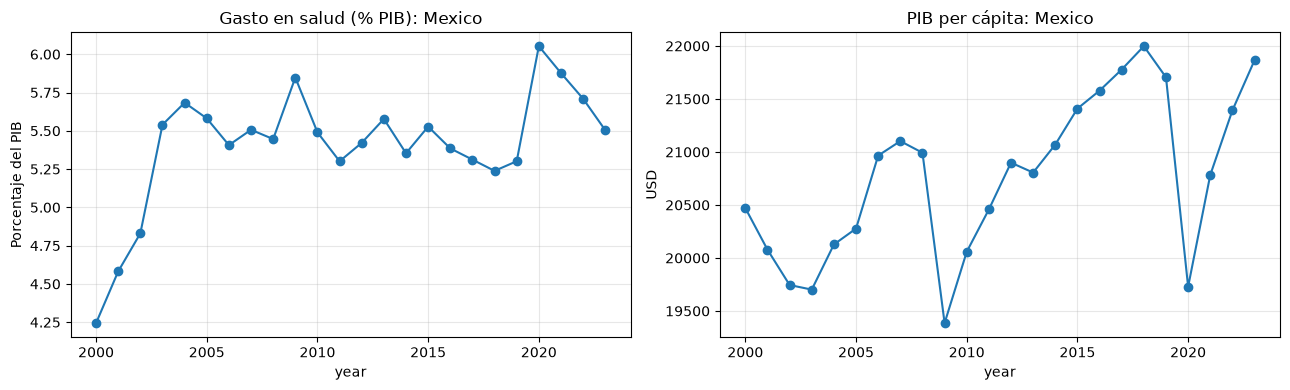

In [8]:
entidad = "Mexico" if "Mexico" in dataset["entity"].values else dataset["entity"].iloc[0]
ejemplo = dataset.loc[dataset["entity"] == entidad].sort_values("year")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejemplo.plot(x="year", y="percentage_health", marker="o", ax=ejes[0], legend=False, title=f"Gasto en salud (% PIB): {entidad}")
ejes[0].set_ylabel("Porcentaje del PIB")
ejemplo.plot(x="year", y="gdp", marker="o", ax=ejes[1], legend=False, title=f"PIB per cápita: {entidad}")
ejes[1].set_ylabel("USD")
for eje in ejes:
    eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Guardar el dataset final

El CSV queda en una carpeta `data/processed` relativa a la ubicación donde se ejecuta el notebook.

In [9]:
carpeta_salida = Path("data/processed")
carpeta_salida.mkdir(parents=True, exist_ok=True)
ruta_salida = carpeta_salida / "dataset_health_percentage_gdp_2000_2023.csv"
dataset.to_csv(ruta_salida, index=False)
print(f"Archivo guardado: {ruta_salida.resolve()}")
print("Columnas entregadas:", dataset.columns.tolist())

Archivo guardado: C:\Users\abrah\Desktop\BIG DATA\U3_Modelos\notebooks\data\processed\dataset_health_percentage_gdp_2000_2023.csv
Columnas entregadas: ['entity', 'year', 'population', 'births', 'deaths', 'child_deaths_under_5', 'percentage_health', 'gdp']
